In [3]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm
from scipy import integrate
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [4]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./real/{fileName}')
    df4 = pd.DataFrame(arff_file[0])
    #drop the outlier and id columns for the independent variables.
    X = df4.drop(columns=['outlier','id']).values
    #get outlier values
    y = df4['outlier'].values
    le = LabelEncoder()
    #encoded the variables as 0=non-outlier, 1=outlier
    y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, median='median'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # index knn and the distance of each value
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="medMax")
        arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr)) #normalize the values
        means = np.mean(arr) # exp function mean value
        inMean = 1 / means
        posNeg4 = []
        spaceStep4 = np.linspace(.9,.99,20) # perform steps from .95 to .99
        for e in spaceStep4:
            ker = -means * np.log(1 - e) # the percentile
            f = integrate.quad(lambda x: inMean * np.exp(-x * inMean), 0, ker)
            newArr = arr > ker # return a new array of values bigger than the percentile
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        arrtest1 = arrtest1.flatten()
        arrtest2 = arrtest2.flatten()
        arrtest1 = (arrtest1-np.min(arrtest1))/(np.max(arrtest1)-np.min(arrtest1)) # normalize the results for ease of use
        arrtest2 = (arrtest2-np.min(arrtest2))/(np.max(arrtest2)-np.min(arrtest2))
        arrtest2 = np.nan_to_num(arrtest2)
        if np.sum(arrtest2) == 0: # if there are zero false positives than return zero
            tots += [1]
        else:
            tots += [integrate.trapezoid(arrtest1, x=-arrtest2)]

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def goodnessOfFit(X,y,kValue):
    knn, distReturn = main(X, y, kValue) # return knn and distance
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax") #
    print(skew(arr)) # check for skewness
    params = expon.fit(arr) # fit the arr generated and get the params
    test = np.linspace(min(arr),max(arr),10)
    # pdfTest = expon.pdf(test,params[0],params[1]) #line used to test the pdf form

    values, edges = np.histogram(arr, bins=int(np.sqrt(len(arr))), density=True) #get values from bins and the edges
    #print(values, edges)
    newX = edges[:-1] + np.diff(edges) # X values from the bins

    pdf_fitted = expon.pdf(newX, loc=params[0], scale=params[1]) # generate a new pdf using the new X values
    residuals = values - pdf_fitted # values vs the generated pdf
    print(pdf_fitted)
    #print(np.dot(residuals, residuals))
    print(sum(pow(residuals, 2) / pdf_fitted)) # prints the chi squared value
    plt.scatter(edges[:-1], values)
    plt.scatter(edges[:-1], pdf_fitted)
    plt.show()

1.0 2 [1.0, 1.0, 0.9705882352941175, 0.9705882352941175, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
1.514840279757903
[0.54553056 0.44810555 0.36807945 0.30234501 0.24834994 0.20399771
 0.16756625 0.13764099 0.11306001 0.09286889 0.07628366 0.06266034
 0.05146998 0.04227808 0.03472774 0.02852579 0.02343144 0.01924687
 0.01580962 0.01298622 0.01066704]
0.43862617909966145


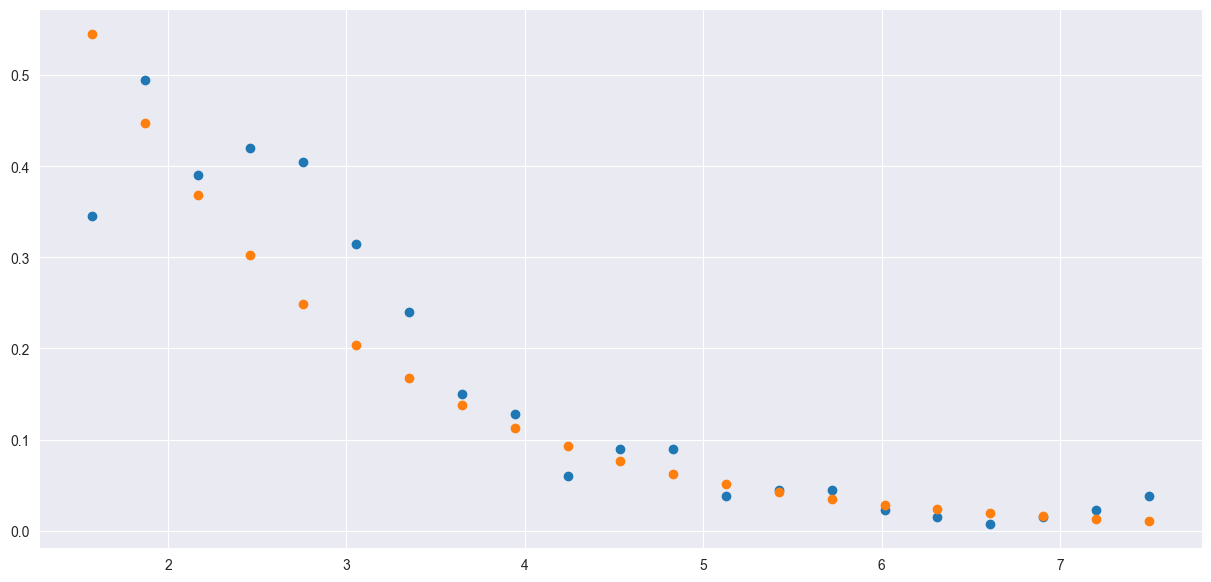

In [5]:
X, y = setupDf("Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,3)

1 2 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
2.3642766368368147
[1.46110198 1.02939767 0.72524681 0.51096185 0.35999057 0.253626
 0.17868843 0.12589227 0.08869553 0.06248912 0.04402578 0.03101771
 0.02185306]
3.8396052104500713


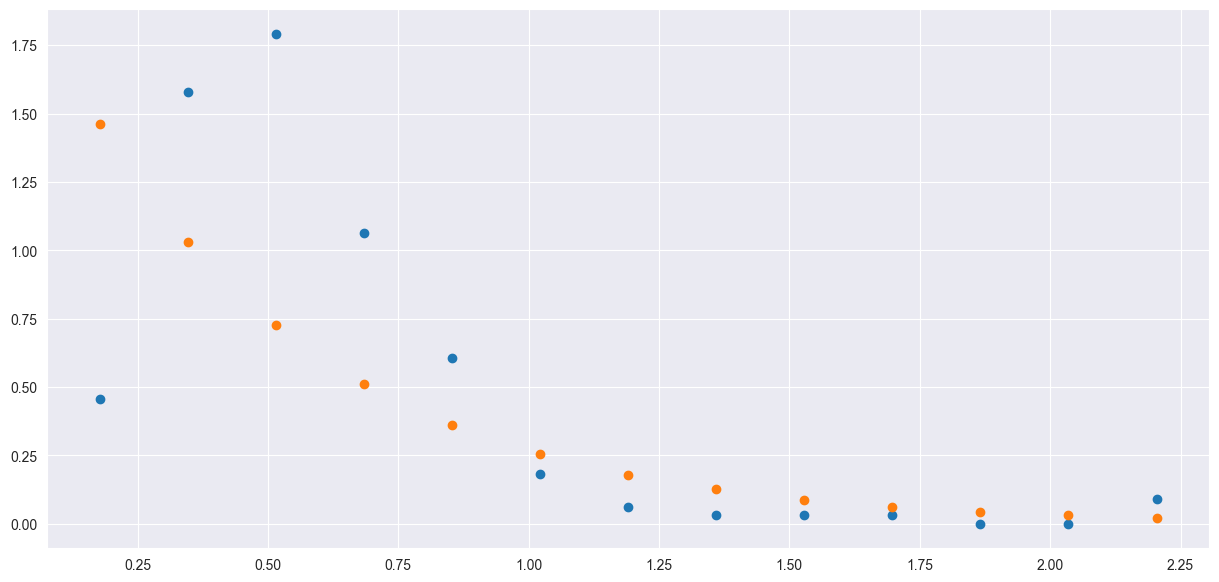

In [6]:
X, y = setupDf("Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,3)

0.9893617021276596 6 [0.0, 0.9230769230769231, 0.9857142857142855, 0.9318181818181819, 0.9893617021276596, 0.9891304347826088, 0.97, 0.92, 0.9259259259259259, 0.923728813559322, 0.8854166666666665, 0.9687500000000001, 0.9117647058823529, 0.951923076923077, 0.8823529411764707, 0.8928571428571429, 0.8545454545454546, 0.8389830508474577, 0.8362068965517242, 0.7457627118644068, 0.725, 0.725, 0.711864406779661, 0.711864406779661, 0.775, 0.7295081967213115, 0.7377049180327868, 0.7377049180327868, 0.7459016393442623, 0.7416666666666667, 0.7416666666666667, 0.7540983606557377, 0.7583333333333333, 0.7580645161290323, 0.7704918032786885, 0.7540983606557377, 0.7622950819672131, 0.7459016393442622, 0.7540983606557377, 0.7542372881355932, 0.7033898305084745, 0.7, 0.6916666666666667, 0.7166666666666667, 0.721311475409836, 0.7540983606557377, 0.7540983606557377, 0.7499999999999999, 0.7916666666666666, 0.7950819672131147, 0.819672131147541, 0.8064516129032258, 0.814516129032258, 0.819672131147541, 0.8

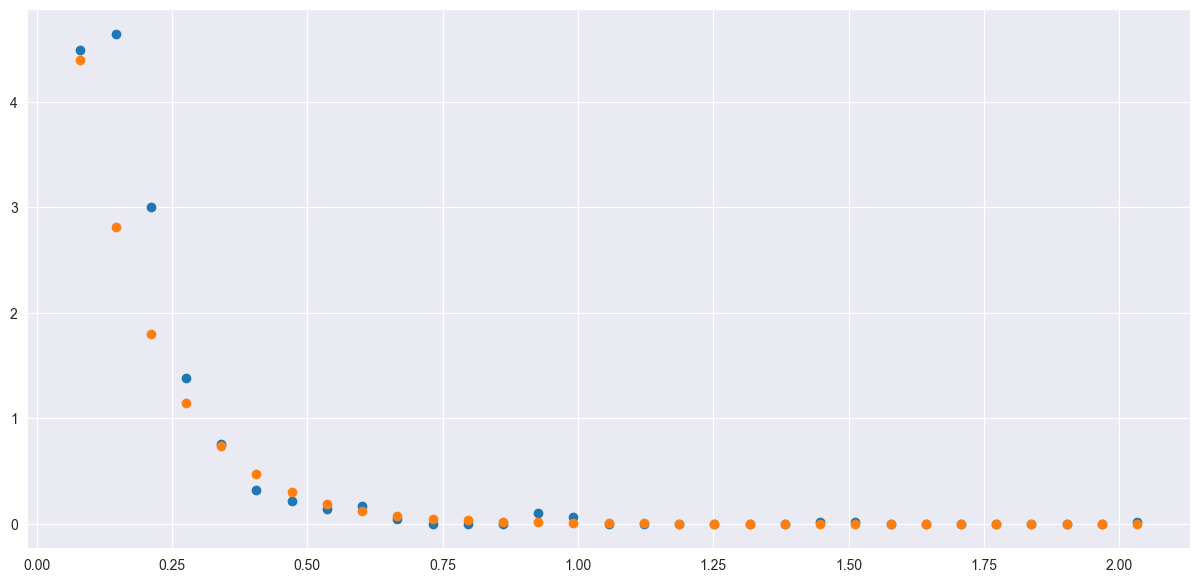

In [7]:
X, y = setupDf("Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,15)

0.8235294117647058 32 [0.4523809523809525, 0.6838235294117647, 0.6477272727272727, 0.5789473684210527, 0.6447368421052632, 0.7105263157894738, 0.7368421052631581, 0.631578947368421, 0.5394736842105263, 0.5657894736842105, 0.5789473684210525, 0.6052631578947368, 0.7236842105263158, 0.7236842105263158, 0.7499999999999999, 0.7631578947368421, 0.7763157894736842, 0.6052631578947368, 0.6052631578947368, 0.6111111111111112, 0.6111111111111112, 0.631578947368421, 0.6578947368421053, 0.638888888888889, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6944444444444444, 0.6666666666666666, 0.6111111111111112, 0.8235294117647058, 0.6470588235294117, 0.676470588235294, 0.676470588235294, 0.676470588235294, 0.7058823529411764, 0.6666666666666666, 0.6666666666666666, 0.6944444444444444, 0.6944444444444444, 0.7222222222222222, 0.7222222222222222, 0.75, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.7222222222222222, 0.6944444444444444, 0.694444444444444

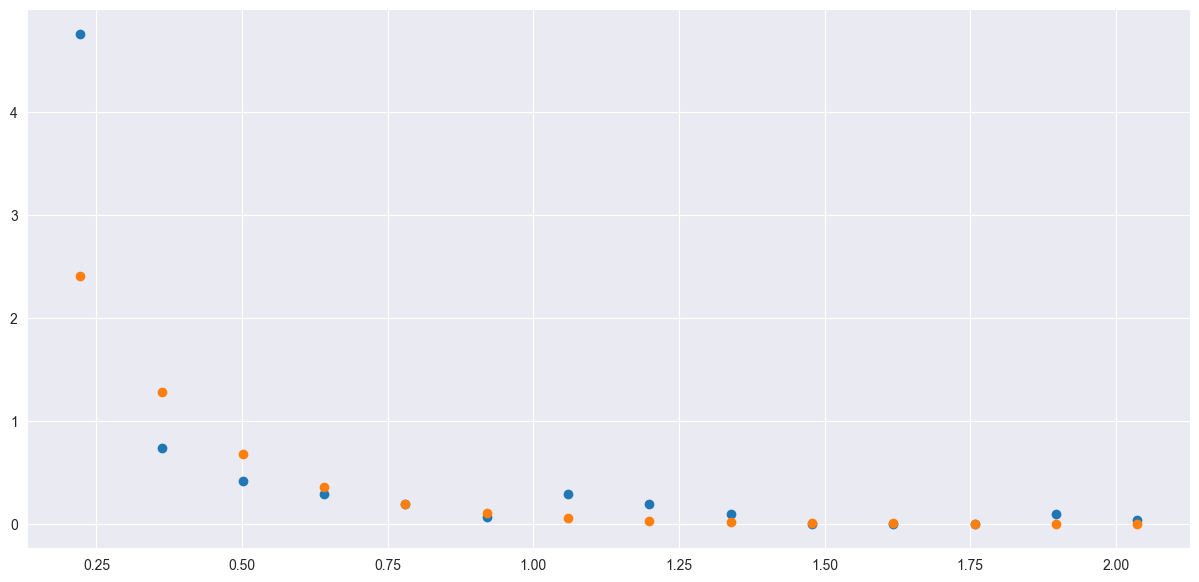

In [8]:
X, y = setupDf("WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,3)

0.558103354978355 20 [0.4704927327079682, 0.460759493670886, 0.4912457912457912, 0.5029905682079595, 0.49428295908527353, 0.47450680744651297, 0.45343353964043615, 0.4837728194726166, 0.4636699507389162, 0.5110110110110109, 0.4955387205387205, 0.5212662337662338, 0.5413473818646232, 0.5457423235201012, 0.5515094926859633, 0.5560782556750299, 0.5556640625, 0.5528041294642858, 0.558103354978355, 0.5424274973147153, 0.5085851648351648, 0.5068993506493507, 0.501082251082251, 0.499800106609808, 0.4867768595041322, 0.48341909662664373, 0.4877296211251435, 0.4987024221453286, 0.4804647785039941, 0.47694955844933395, 0.49291044776119397, 0.4751975417032484, 0.4924901740595171, 0.5004773595199127, 0.49902656097900155, 0.49089635854341734, 0.48543417366946773, 0.4841036414565826, 0.48491169517452365, 0.4901960784313725, 0.4947101142615319, 0.5017142857142857, 0.494047619047619, 0.4833104395604395, 0.481043956043956, 0.4866694879390605, 0.48427140640428834, 0.4871412333049162, 0.49033920137398024

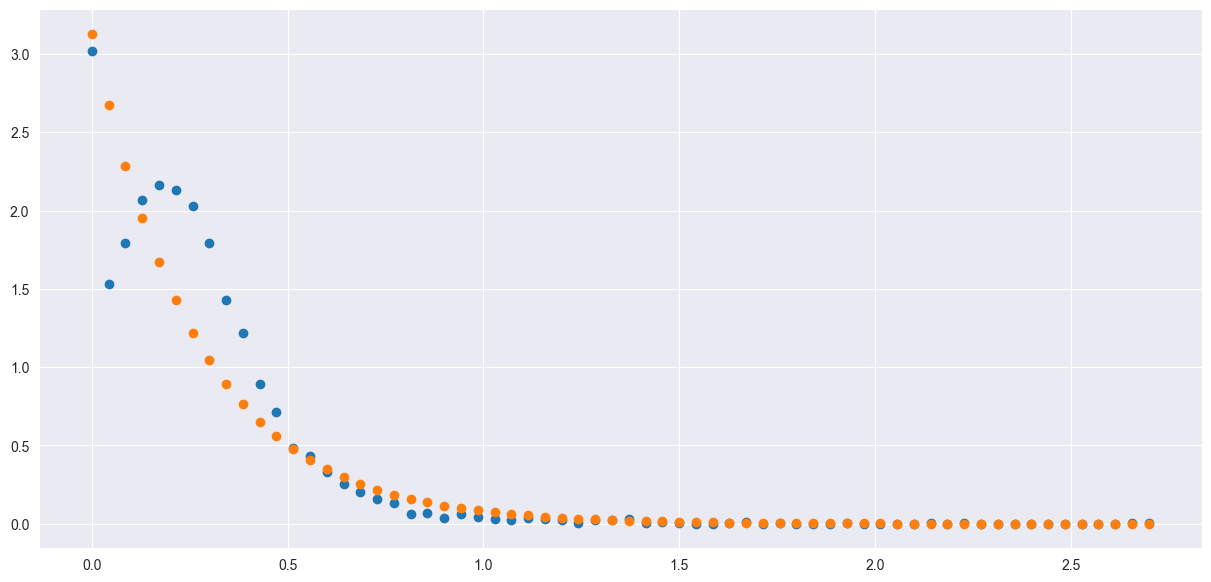

In [9]:
X, y = setupDf("SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,3)

0.548076923076923 42 [0.25, 0.38888888888888884, 0.275, 0.5, 0.37499999999999994, 0.34090909090909083, 0.45833333333333337, 0.3636363636363636, 0.4375, 0.49999999999999994, 0.5192307692307692, 0.380952380952381, 0.375, 0.4027777777777778, 0.41666666666666663, 0.39423076923076916, 0.43269230769230765, 0.4553571428571428, 0.46428571428571414, 0.34615384615384615, 0.2916666666666667, 0.3854166666666666, 0.43269230769230765, 0.4326923076923076, 0.43269230769230765, 0.38541666666666663, 0.38541666666666663, 0.43749999999999994, 0.39583333333333326, 0.4166666666666666, 0.4374999999999999, 0.4903846153846153, 0.49999999999999994, 0.4903846153846153, 0.4903846153846153, 0.42708333333333326, 0.5192307692307692, 0.48958333333333326, 0.4791666666666666, 0.5288461538461537, 0.548076923076923, 0.43181818181818177, 0.4431818181818181, 0.48958333333333326, 0.4431818181818181, 0.4431818181818181, 0.4431818181818181, 0.3749999999999999, 0.3749999999999999, 0.3999999999999999, 0.34090909090909083, 0.363

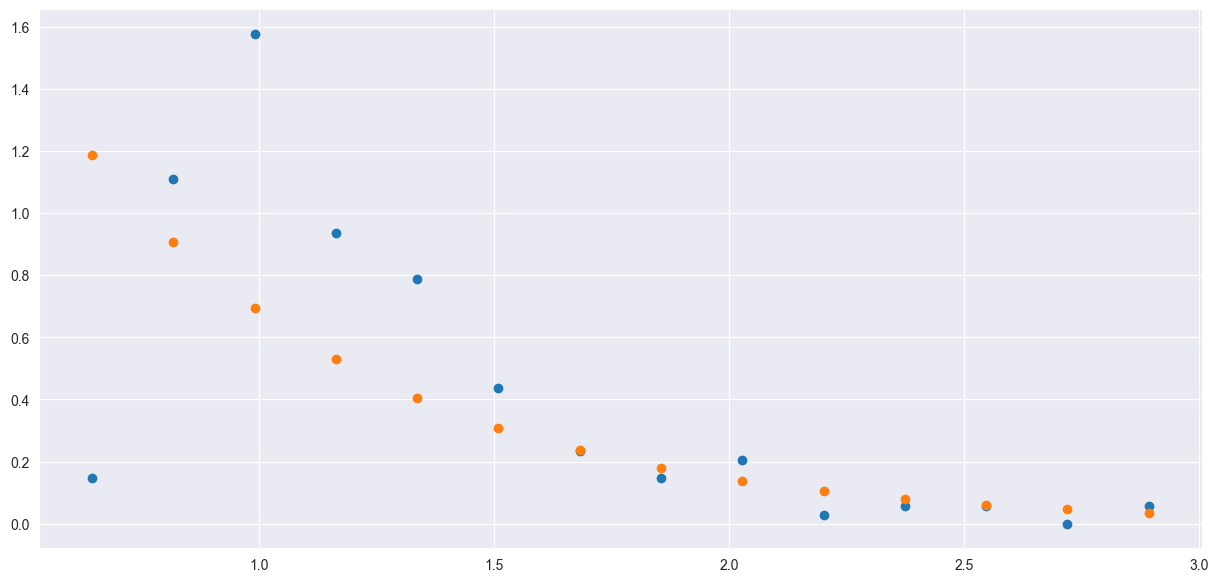

In [10]:
X, y = setupDf("WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)

1.0 5 [0.42857142857142855, 0.6666666666666666, 0.7000000000000001, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8, 0.8500000000000001, 0.8, 0.8500000000000001, 0.7000000000000001, 0.875, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8333333333333333, 0.8333333333333331, 0.8333333333333331, 0.8166666666666665, 0.9800000000000001, 1.0, 1.0, 1.0]
0.823550179177848
[1.12123846 0.93349079 0.77718085 0.64704449 0.53869903 0.44849566
 0.37339655 0.31087253 0.25881795 0.21547974 0.17939837 0.14935871
 0.12434909 0.10352724 0.08619195 0.07175939]
2.234297399816517


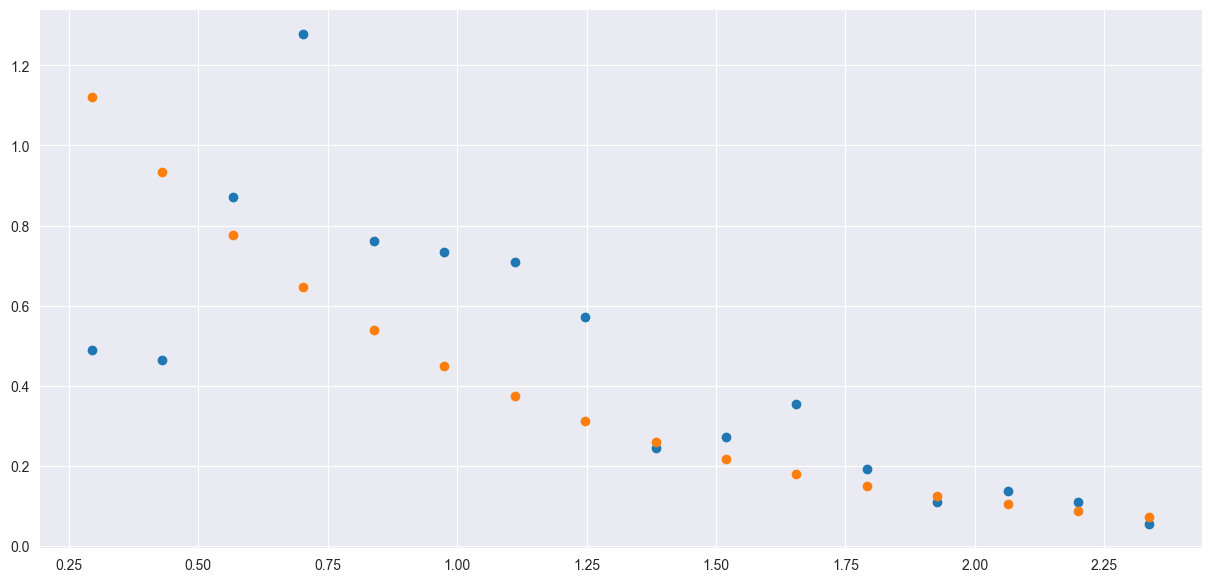

In [11]:
X, y = setupDf("HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)

0.8881578947368421 63 [0.31666666666666665, 0.36718749999999994, 0.4407894736842105, 0.65, 0.638888888888889, 0.6323529411764706, 0.638888888888889, 0.631578947368421, 0.5833333333333334, 0.5277777777777779, 0.47058823529411775, 0.47058823529411775, 0.5, 0.5138888888888888, 0.5263157894736843, 0.5, 0.47058823529411775, 0.5263157894736843, 0.5, 0.5, 0.5125, 0.4736842105263158, 0.4625, 0.43421052631578955, 0.4523809523809524, 0.4210526315789474, 0.3611111111111111, 0.3289473684210526, 0.33333333333333326, 0.26315789473684215, 0.23611111111111105, 0.4722222222222221, 0.46296296296296285, 0.6805555555555555, 0.6805555555555555, 0.6805555555555555, 0.6805555555555555, 0.6617647058823529, 0.6805555555555555, 0.6617647058823529, 0.6617647058823529, 0.6805555555555554, 0.6944444444444444, 0.6973684210526316, 0.6944444444444444, 0.8020833333333333, 0.79, 0.8076923076923077, 0.8333333333333333, 0.8392857142857143, 0.8392857142857143, 0.853448275862069, 0.8548387096774193, 0.8548387096774193, 0.8

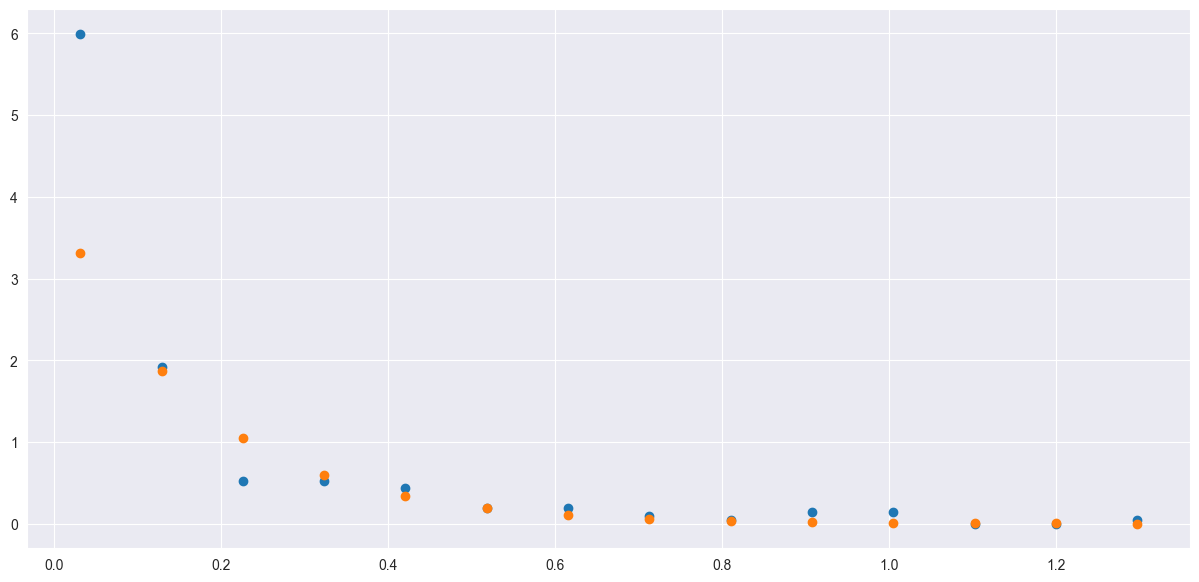

In [12]:
X, y = setupDf("Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)

1.0 2 [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33333333333333326, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.25, 0.0, 0.0, 0.0, 0.0, 0.0]
-0.6424341698737143
[0.41571527 0.33532767 0.27048476 0.21818065 0.17599067 0.14195904
 0.11450817 0.09236552]
3.334529614417651


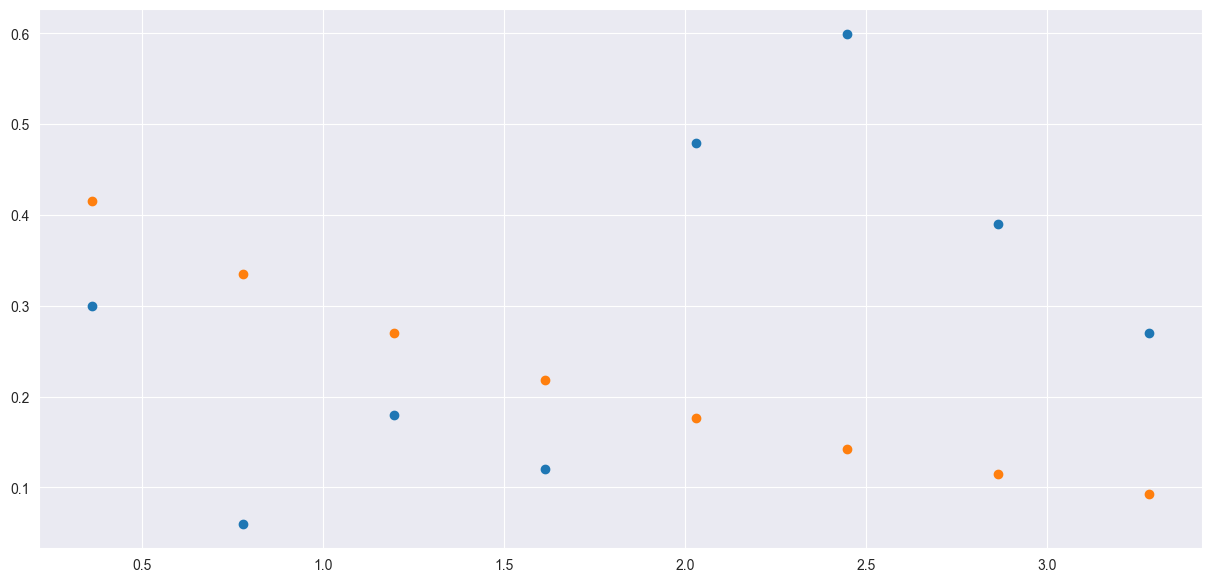

In [13]:
X, y = setupDf("Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)

0.6714285714285714 2 [0.6714285714285714, 0.6428571428571428, 0.6092436974789914, 0.5249999999999999, 0.5491452991452992, 0.6052631578947368, 0.5925925925925926, 0.5954861111111112, 0.5515873015873015, 0.5814814814814815, 0.632716049382716, 0.6140350877192983, 0.5862573099415205, 0.5648148148148149, 0.5332409972299169, 0.5062500000000001, 0.53, 0.6161764705882354, 0.5743034055727555, 0.5277777777777779, 0.4833333333333332, 0.4922839506172839, 0.4795321637426899, 0.45277777777777767, 0.41456582633053213, 0.45238095238095233, 0.44179894179894175, 0.48148148148148145, 0.45833333333333326, 0.45959595959595956, 0.46875, 0.48495370370370366, 0.4768518518518518, 0.4768518518518518, 0.480324074074074, 0.4814814814814814, 0.49451754385964913, 0.49890350877192985, 0.5098684210526316, 0.4942129629629629, 0.47800925925925924, 0.48495370370370366, 0.48148148148148145, 0.506578947368421, 0.4936842105263158, 0.48947368421052634, 0.5270833333333333, 0.499, 0.504, 0.48315789473684206, 0.488421052631578

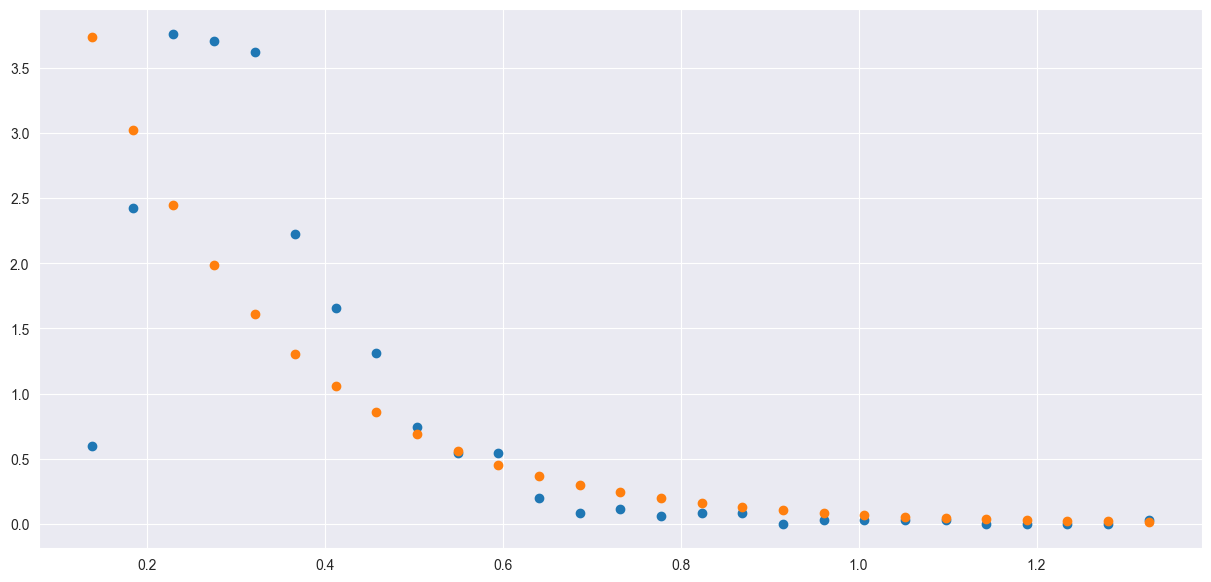

In [14]:
X, y = setupDf("Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)

0.8580927835051546 20 [0.6672494172494172, 0.5762925598991173, 0.5483058608058609, 0.6599144951140065, 0.6466655237442139, 0.6708850931677017, 0.6991590214067278, 0.7516901408450704, 0.7885117493472584, 0.7960256410256411, 0.8212804878048781, 0.828095238095238, 0.8300000000000001, 0.8235781990521328, 0.8329676674364896, 0.8501075268817203, 0.8535940803382663, 0.8577442827442828, 0.8580927835051546, 0.8558044806517312, 0.8485386221294363, 0.8531837160751566, 0.8540650406504064, 0.8450592885375493, 0.8529092702169625, 0.8519417475728156, 0.8507797270955165, 0.8371047430830039, 0.8437980769230771, 0.8347408829174664, 0.8372410546139359, 0.8354089219330856, 0.8348148148148149, 0.8298623853211008, 0.8323608617594255, 0.8218297101449274, 0.8224689165186502, 0.8263548951048952, 0.8189380530973452, 0.8089285714285713, 0.8048230088495576, 0.7995080500894454, 0.7902154398563733, 0.7817652329749103, 0.7738918439716311, 0.7718309859154929, 0.7718804159445406, 0.7619210977701544, 0.7734924623115578

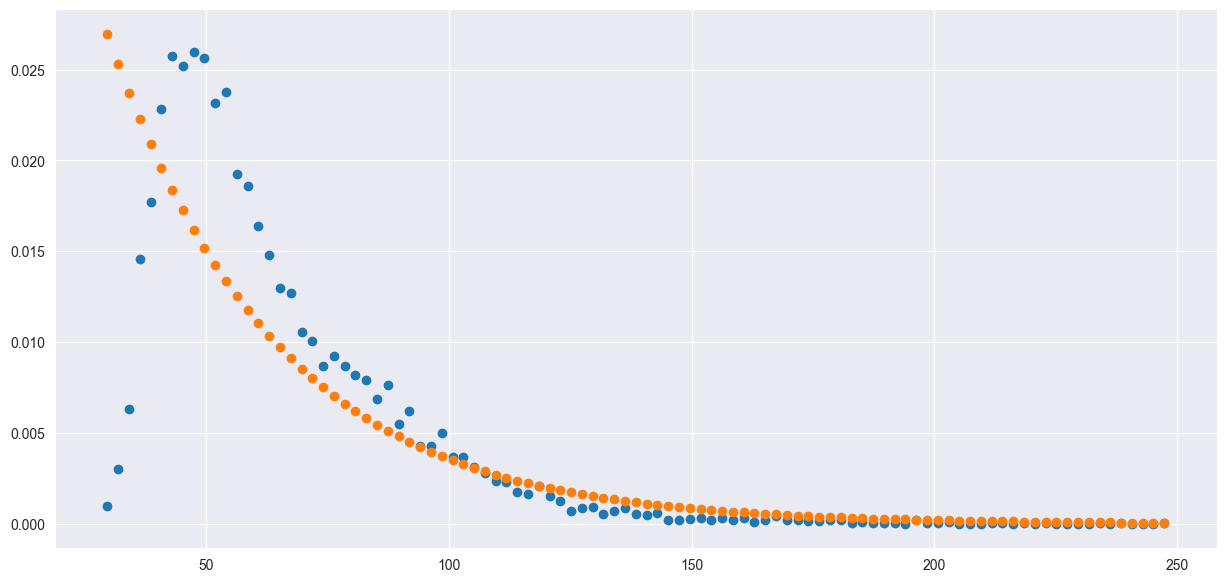

In [16]:
X, y = setupDf("PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 20)